In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime 
df = pd.read_csv('../data/raw/creditcard.csv')
print(df.shape)
print(df.head())
print(df.info())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


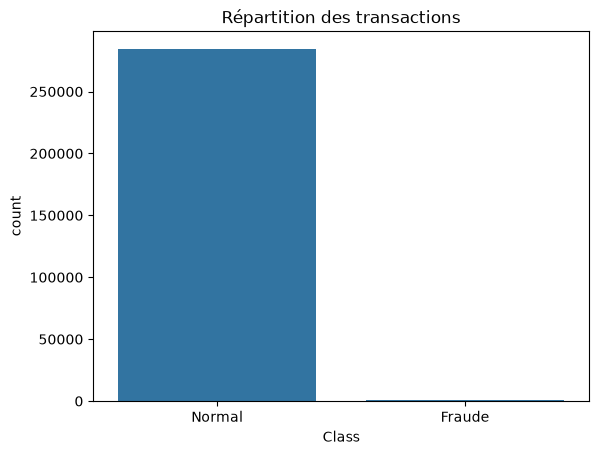

In [2]:
# Répartition des classes
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

# Visualisation
sns.countplot(x='Class', data=df)
plt.title('Répartition des transactions')
plt.xticks([0, 1], ['Normal', 'Fraude'])
plt.show()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


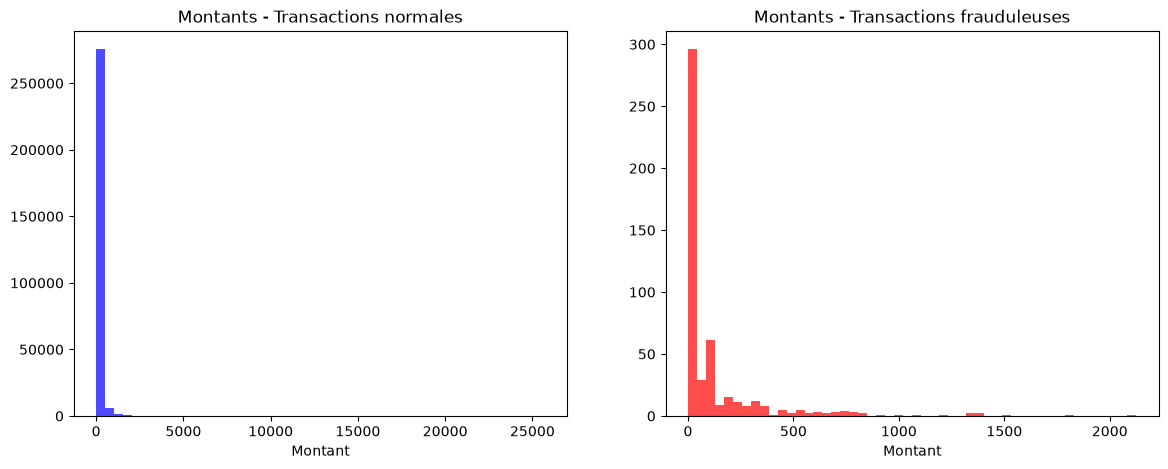

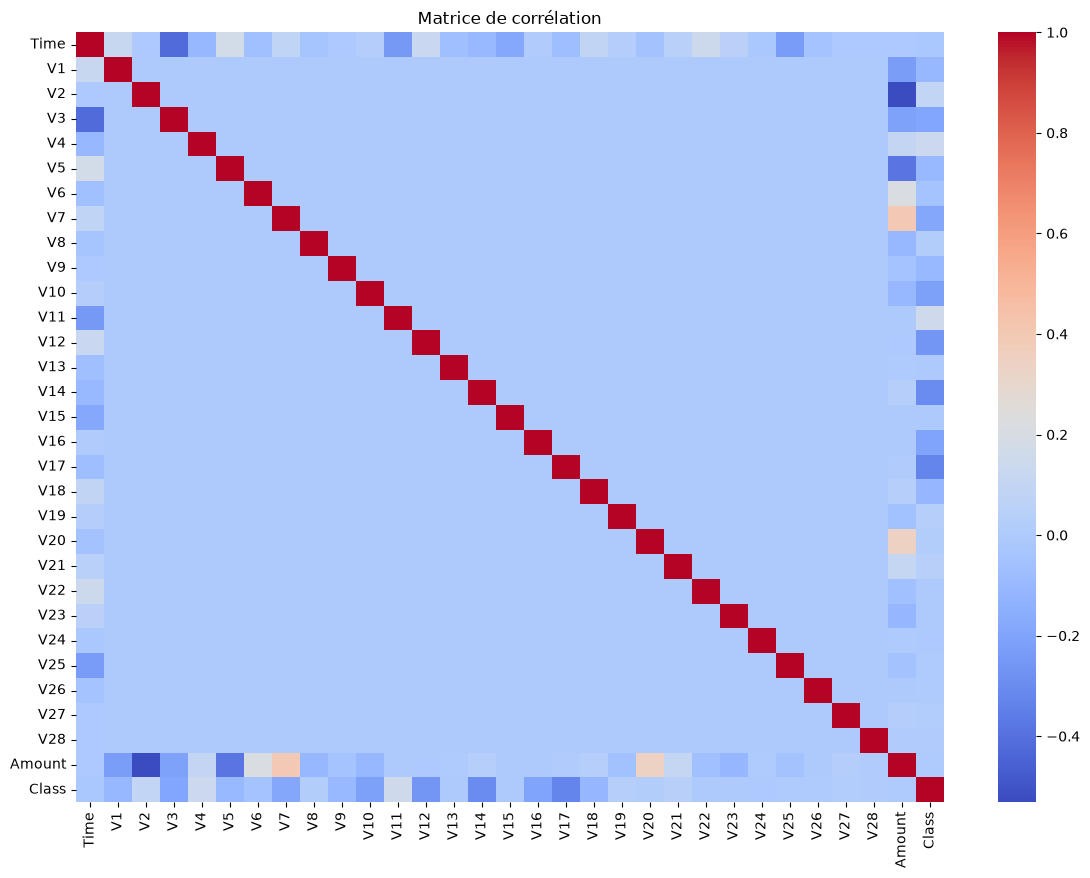

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

# Copie du dataframe
df_processed = df.copy()

# Normalisation de Amount et Time
scaler = StandardScaler()
df_processed['Amount'] = scaler.fit_transform(df_processed[['Amount']])
df_processed['Time'] = scaler.fit_transform(df_processed[['Time']])

# Vérification
print(df_processed[['Time', 'Amount']].describe())

               Time        Amount
count  2.848070e+05  2.848070e+05
mean  -5.109395e-17 -3.672378e-17
std    1.000002e+00  1.000002e+00
min   -1.996583e+00 -3.532294e-01
25%   -8.552120e-01 -3.308401e-01
50%   -2.131453e-01 -2.652715e-01
75%    9.372174e-01 -4.471707e-02
max    1.642058e+00  1.023622e+02


In [12]:
from sklearn.model_selection import train_test_split

# Séparation features et target
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# Split train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.value_counts()}")
print(f"y_test  : {y_test.value_counts()}")

X_train : (199364, 30)
X_test  : (85443, 30)
y_train : Class
0    199020
1       344
Name: count, dtype: int64
y_test  : Class
0    85295
1      148
Name: count, dtype: int64


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts()}")
print(f"Après SMOTE : {y_train_res.value_counts()}")

Avant SMOTE : Class
0    199020
1       344
Name: count, dtype: int64
Après SMOTE : Class
0    199020
1    199020
Name: count, dtype: int64


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

y_pred = rf.predict(X_test)

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Matrice de confusion :
[[85277    18]
 [   31   117]]

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.93      0.90      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Entraînement
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_res, y_train_res)

# Prédiction
y_pred = model.predict(X_test)

# Évaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.93      0.90      0.91     85443
weighted avg       1.00      1.00      1.00     85443

[[85277    18]
 [   31   117]]


In [16]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("Matrice de confusion XGBoost :")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nRapport de classification XGBoost :")
print(classification_report(y_test, y_pred_xgb))

Matrice de confusion XGBoost :
[[85256    39]
 [   29   119]]

Rapport de classification XGBoost :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.75      0.80      0.78       148

    accuracy                           1.00     85443
   macro avg       0.88      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [17]:
from sklearn.model_selection import GridSearchCV

# Paramètres à tester
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score :", grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur score : 0.9999949753793588


In [18]:
# Modèle optimisé
best_rf = RandomForestClassifier(
    max_depth=20,
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X_train_res, y_train_res)

y_pred_best = best_rf.predict(X_test)

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_best))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_best))

Matrice de confusion :
[[85262    33]
 [   30   118]]

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.78      0.80      0.79       148

    accuracy                           1.00     85443
   macro avg       0.89      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



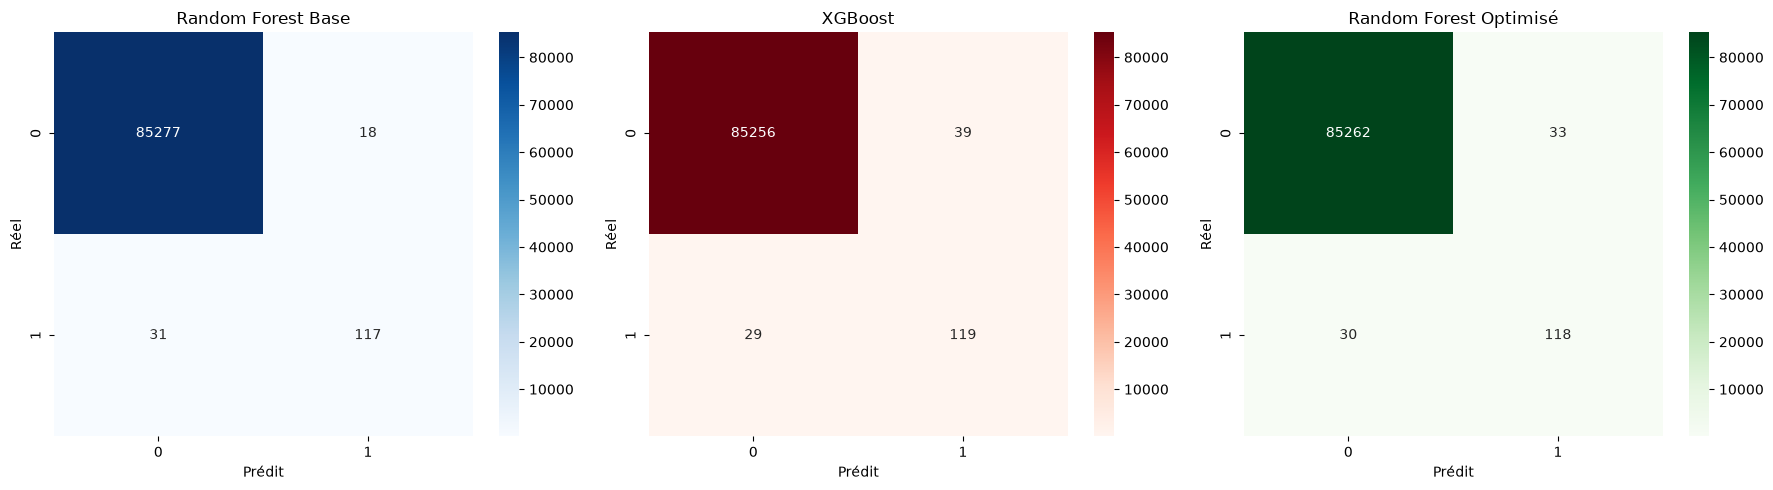

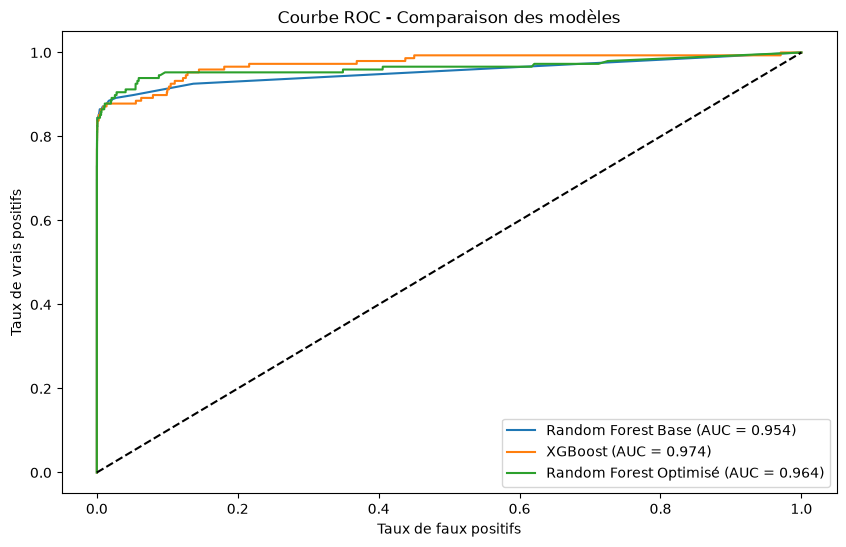

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 1. Matrice de confusion visuelle
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Random Forest Base': (rf, 'Blues'),
    'XGBoost': (xgb, 'Reds'),
    'Random Forest Optimisé': (best_rf, 'Greens')
}

for ax, (name, (model, color)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

# 2. Courbe ROC
plt.figure(figsize=(10, 6))
for name, (model, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC - Comparaison des modèles')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score

# Définir le classifier
clf = RandomForestClassifier(random_state=42, class_weight="balanced")

# Sélection automatique des meilleures features
rfecv = RFECV(estimator=clf, step=1, cv=StratifiedKFold(5), scoring='roc_auc')

# Pipeline
pipeline = Pipeline([
    ('feature_selection', rfecv),
    ('classification', clf)
])

# Paramètres à tester
param_grid = {
    'classification__n_estimators': [100, 200],
    'classification__max_features': ['sqrt', 'log2'],
    'classification__max_depth': [5, 10, None],
    'classification__criterion': ['gini', 'entropy']
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entraînement
grid_search.fit(X_train_res, y_train_res)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score :", grid_search.best_score_)

# Évaluation sur le test
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score :", roc_auc)